In [1]:
# ============================================================
# Smart Manufacturing Data Analytics and Predictive Maintenance
# Notebook 01: Exploratory Data Analysis (EDA)
# Author: Opurva Saini
# ============================================================

# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display all columns
pd.set_option("display.max_columns", None)

print("✅ Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries imported successfully!


In [2]:
# Load dataset

df = pd.read_csv("../dataset/ai4i2020.csv")

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Rows and Columns")

print(df.shape)

Rows and Columns
(10000, 14)


In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [ ]:
#Missing Values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
#Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [ ]:
#Target Variable Distribution
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

UDI
10000
----------------------------------------
Product ID
10000
----------------------------------------
Type
3
----------------------------------------
Air temperature [K]
93
----------------------------------------
Process temperature [K]
82
----------------------------------------
Rotational speed [rpm]
941
----------------------------------------
Torque [Nm]
577
----------------------------------------
Tool wear [min]
246
----------------------------------------
Machine failure
2
----------------------------------------
TWF
2
----------------------------------------
HDF
2
----------------------------------------
PWF
2
----------------------------------------
OSF
2
----------------------------------------
RNF
2
----------------------------------------


In [11]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

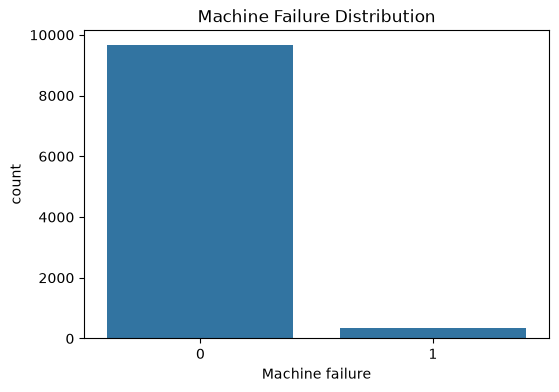

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")

plt.show()

In [13]:
failure_counts = df["Machine failure"].value_counts()

print(failure_counts)
print()

failure_percentage = (failure_counts / len(df)) * 100

print(failure_percentage)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    96.61
1     3.39
Name: count, dtype: float64


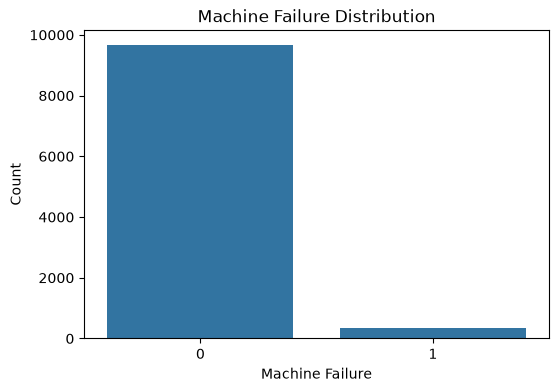

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

### Observation

- Majority of machines are working normally.
- Only a small percentage experienced failures.
- The dataset is imbalanced, which is common in predictive maintenance problems.

In [17]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

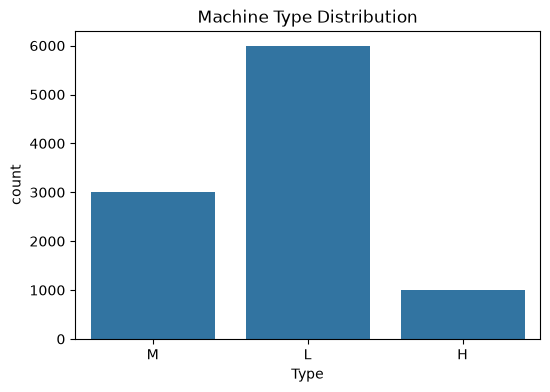

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Type")

plt.title("Machine Type Distribution")

plt.show()

### Business Insight

The dataset contains three categories of machines:

- L (Low Quality)
- M (Medium Quality)
- H (High Quality)

Understanding machine type helps determine whether a particular category is more prone to failures.

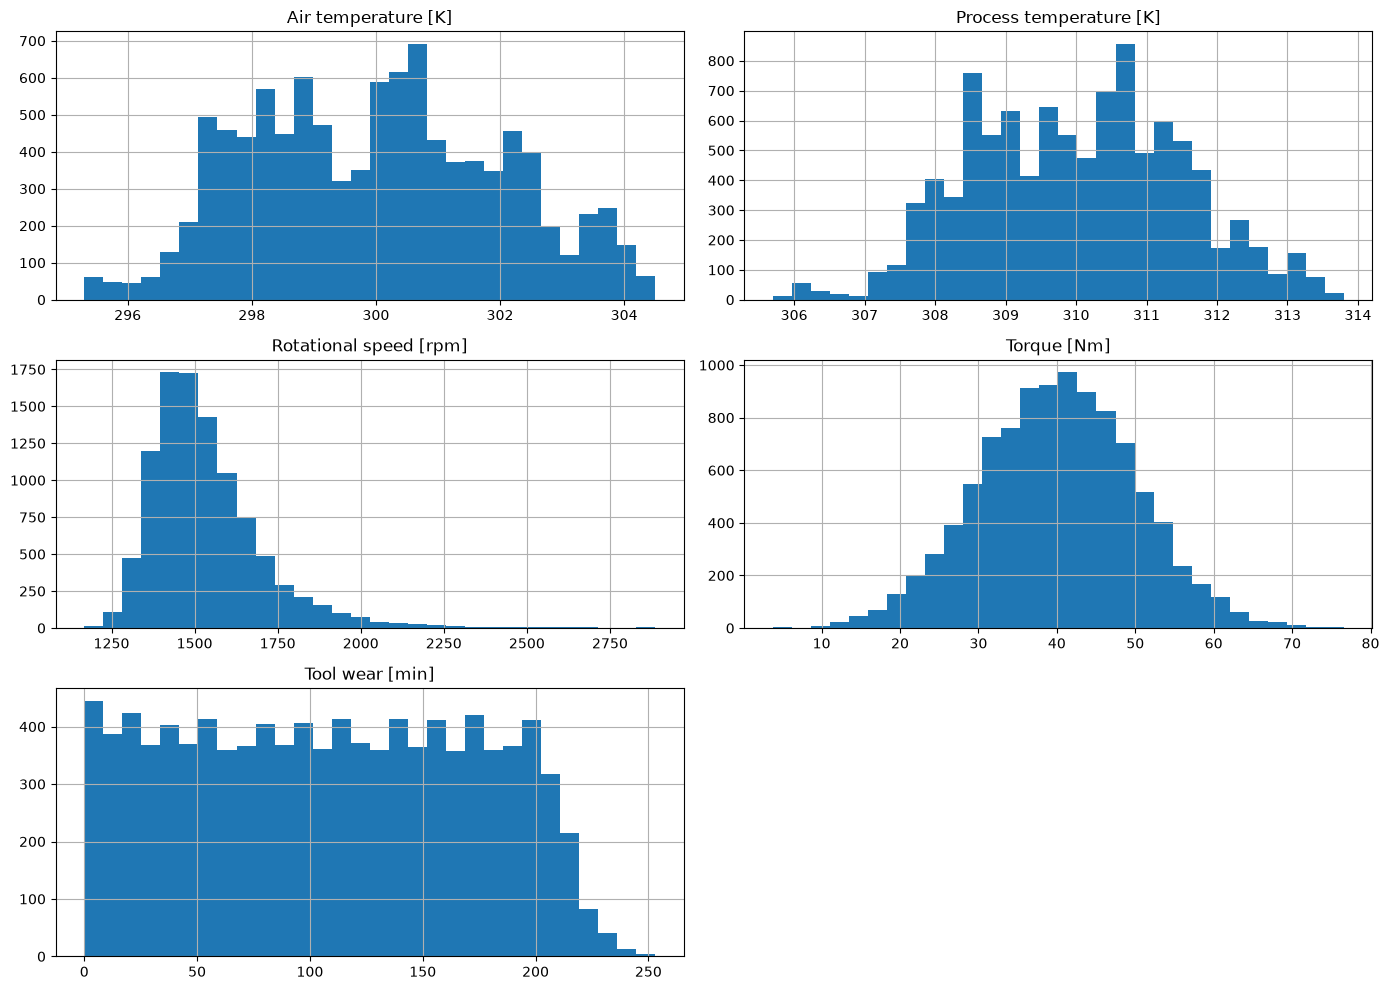

In [ ]:
#Numerical Feature Distribution

numerical_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numerical_columns].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()

plt.show()

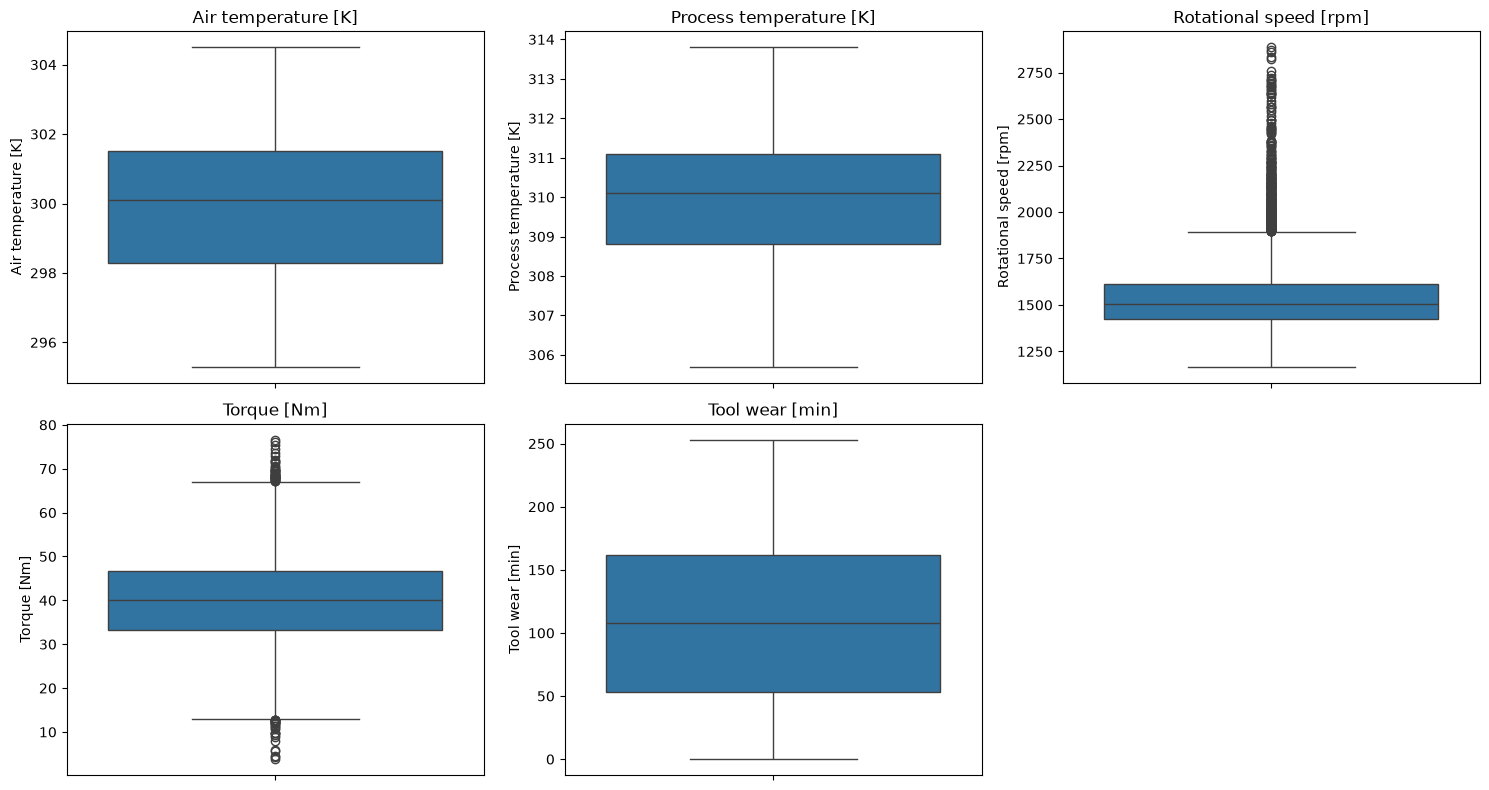

In [16]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

Rotational speed contains outliers.
Tool wear has wide variation.
Air temperature is nearly normally distributed.

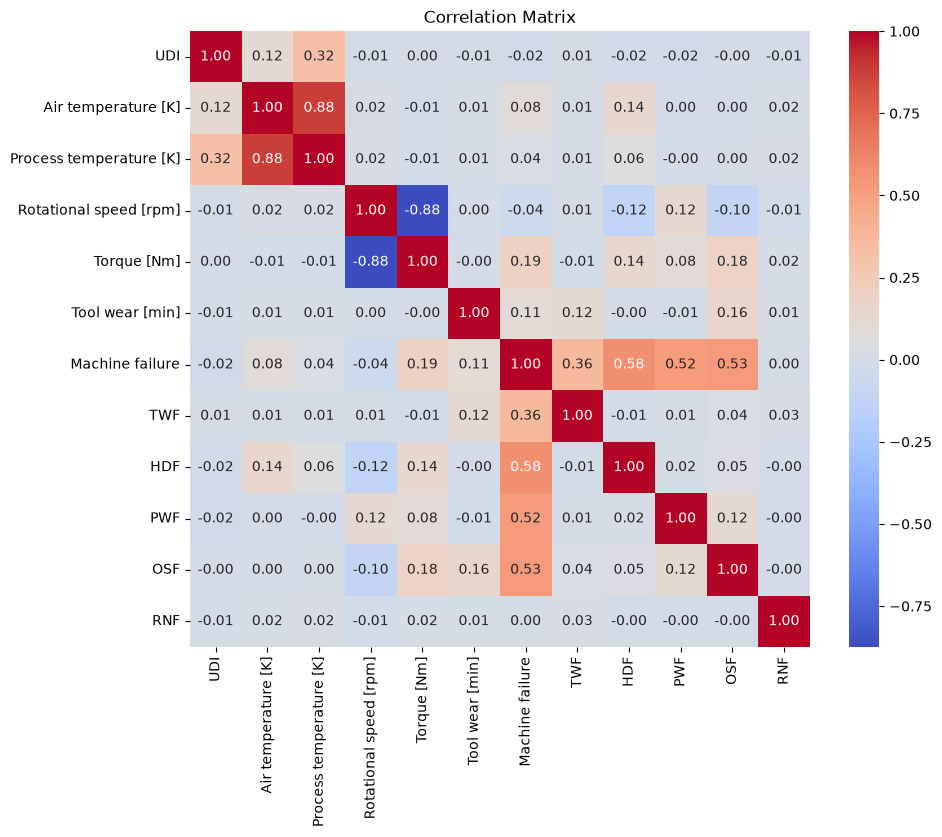

In [20]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#Failure Type Analysis
failure_types = ["TWF","HDF","PWF","OSF","RNF"]

for col in failure_types:
    print(col)
    print(df[col].value_counts())
    print("-"*30)

TWF
TWF
0    9954
1      46
Name: count, dtype: int64
------------------------------
HDF
HDF
0    9885
1     115
Name: count, dtype: int64
------------------------------
PWF
PWF
0    9905
1      95
Name: count, dtype: int64
------------------------------
OSF
OSF
0    9902
1      98
Name: count, dtype: int64
------------------------------
RNF
RNF
0    9981
1      19
Name: count, dtype: int64
------------------------------


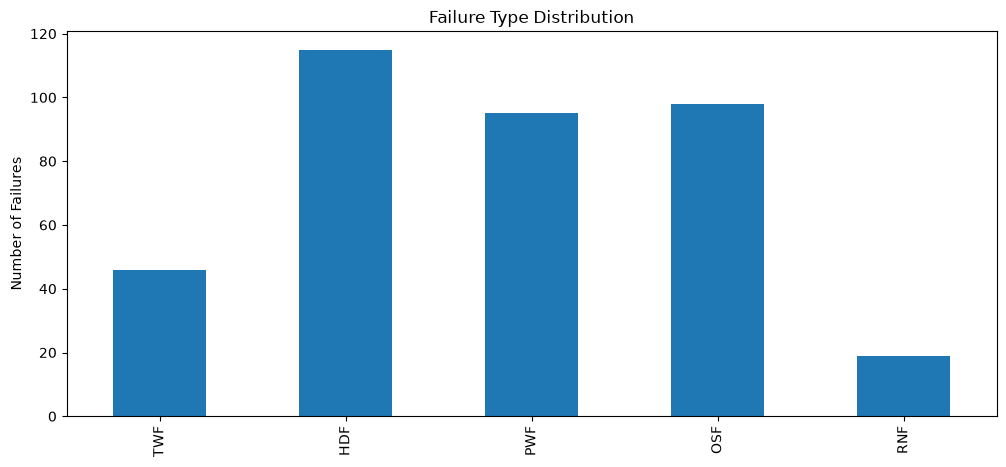

In [22]:
plt.figure(figsize=(12,5))

failure_totals = df[failure_types].sum()

failure_totals.plot(
    kind="bar"
)

plt.title("Failure Type Distribution")

plt.ylabel("Number of Failures")

plt.show()

Business Insight

Random Failures are rare.

Heat Dissipation Failure and Overstrain Failure occur more frequently.

Different failure mechanisms require different maintenance strategies.

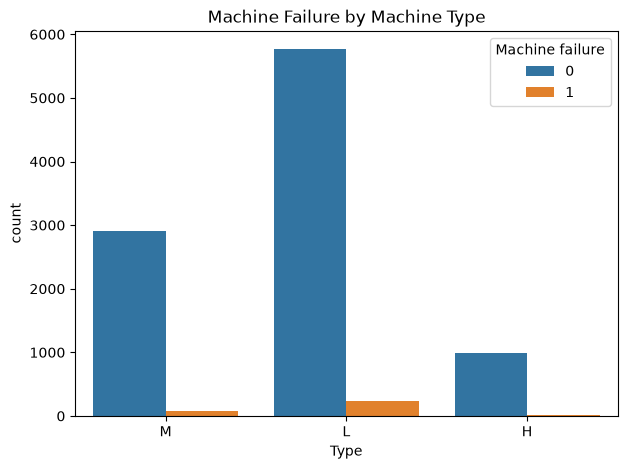

In [23]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure"
)

plt.title("Machine Failure by Machine Type")

plt.show()

# Key Insights

- Dataset is clean with no missing values.
- Machine failure is highly imbalanced.
- Numerical features show realistic industrial ranges.
- Machine type influences operational characteristics.
- Different failure mechanisms have different frequencies.
- Correlation analysis helps identify important predictive variables.

# Conclusion

This exploratory analysis provided a comprehensive understanding of the AI4I 2020 predictive maintenance dataset.

The dataset is clean, well-structured, and suitable for machine learning. Several operational parameters, including rotational speed, torque, tool wear, and temperature-related variables, exhibit meaningful relationships with machine failures. The observed class imbalance suggests that specialized preprocessing techniques will be required before model training.

The insights obtained from this analysis will guide the feature engineering and preprocessing steps in the next notebook.
